# Parte 3: Modelo A vs. Modelo B

## Comparacao e Recomendacao

**Objetivo**: Comparar o modelo A com o modelo B e recomendar, com base em evidencias estatisticas, se devemos ou nao substituir o modelo atual.

In [18]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2

from sklearn.metrics import classification_report
from sklearn.calibration import calibration_curve
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.contingency_tables import SquareTable
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

DADOS_PATH = Path('../dados/chamados_com_predicoes.csv')
FIGURES_PATH = Path('../results/figures/')

In [2]:
cat_map = {
    "iluminacao_publica": "Iluminação Pública",
    "buraco_via": "Buraco em Via",
    "coleta_lixo": "Coleta de Lixo",
    "esgoto_vazamento": "Vazamento de Esgoto",
    "poda_arvore": "Poda de Árvore",
    "estacionamento_irregular": "Estacionamento Irregular",
    "barulho_perturbacao": "Barulho / Perturbação",
    "sinalizacao": "Sinalização",
}


## 4. Devemos Trocar de Modelo?

In [3]:
df = pd.read_csv(DADOS_PATH, encoding="utf-8")
df["data_abertura"] = pd.to_datetime(df["data_abertura"])

categorias = sorted(df["categoria_real"].unique())

In [4]:
y_true = df["categoria_real"]
y_pred_a = df["pred_modelo_a"]
y_pred_b = df["pred_modelo_b"]

a_certo = (y_pred_a == y_true)
b_certo = (y_pred_b == y_true)

n11 = (a_certo & b_certo).sum()  # ambos certos
n10 = (a_certo & ~b_certo).sum()  # A certo, B errado
n01 = (~a_certo & b_certo).sum()  # A errado, B certo
n00 = (~a_certo & ~b_certo).sum()  # ambos errados

print(f'Casos onde A acertou e B errou: {n10}')
print(f'Casos onde A errou e B acertou: {n01}')
print(f'Diferença líquida a favor de B: {n01 - n10}')

Casos onde A acertou e B errou: 517
Casos onde A errou e B acertou: 991
Diferença líquida a favor de B: 474


In [5]:
# Teste McNemar
table = [
    [n11, n01],
    [n10, n00]
]

resultado = mcnemar(
    table,
    exact=False,
    correction=True
)

print(f"Estatística: {resultado.statistic:.4f}")
print(f"p-valor: {resultado.pvalue:.6f}")

Estatística: 148.3614
p-valor: 0.000000


### 4.1. Comparação por Categoria

In [6]:
tabela = pd.crosstab(y_pred_a, y_pred_b)
# Teste de Stuart–Maxwell
resultado = SquareTable(tabela).homogeneity()

print(resultado)

df          7
pvalue      0.0
statistic   128.18420372297822


In [7]:
print("Modelo A")
print(classification_report(y_true, y_pred_a))

print("Modelo B")
print(classification_report(y_true, y_pred_b))

Modelo A
                          precision    recall  f1-score   support

     barulho_perturbacao       0.80      0.78      0.79       400
              buraco_via       0.66      0.82      0.73       908
             coleta_lixo       0.81      0.81      0.81       806
        esgoto_vazamento       0.71      0.58      0.64       621
estacionamento_irregular       0.80      0.83      0.81       437
      iluminacao_publica       0.86      0.79      0.82      1143
             poda_arvore       0.80      0.78      0.79       458
             sinalizacao       0.74      0.80      0.77       227

                accuracy                           0.77      5000
               macro avg       0.77      0.77      0.77      5000
            weighted avg       0.78      0.77      0.77      5000

Modelo B
                          precision    recall  f1-score   support

     barulho_perturbacao       0.85      0.88      0.86       400
              buraco_via       0.87      0.92      0.8

In [8]:
resultados = []

for cat, df_cat in df.groupby("categoria_real"):

    y_true_cat = df_cat["categoria_real"]
    y_pred_cat_a = df_cat["pred_modelo_a"]
    y_pred_cat_b = df_cat["pred_modelo_b"]

    a_certo_cat = (y_pred_cat_a == y_true_cat)
    b_certo_cat = (y_pred_cat_b == y_true_cat)

    n11 = (a_certo_cat & b_certo_cat).sum()
    n10 = (a_certo_cat & ~b_certo_cat).sum()
    n01 = (~a_certo_cat & b_certo_cat).sum()
    n00 = (~a_certo_cat & ~b_certo_cat).sum()

    table = [[n11, n01],
             [n10, n00]]

    resultado = mcnemar(
        table,
        exact=False,
        correction=True
    )

    estatistica = resultado.statistic
    pvalor = resultado.pvalue

    resultados.append({
        "Categoria": cat,
        "N": len(df_cat),
        "Acc_A": a_certo_cat.mean(),
        "Acc_B": b_certo_cat.mean(),
        "n10": n10,
        "n01": n01,
        "Diferença": a_certo_cat.mean() - b_certo_cat.mean(),
        "p-valor": pvalor
    })

resultado_categoria = pd.DataFrame(resultados)
resultado_categoria

,Categoria,N,Acc_A,Acc_B,n10,n01,Diferença,p-valor
0,barulho_perturbacao,400,0.775000,0.880000,32,74,-0.105000,6.825959e-05
1,buraco_via,908,0.817181,0.917401,64,155,-0.100220,1.189621e-09
2,coleta_lixo,806,0.806452,0.916873,53,142,-0.110422,2.941880e-10
3,esgoto_vazamento,621,0.578100,0.888889,47,240,-0.310789,8.965387e-30
4,estacionamento_irregular,437,0.826087,0.897025,39,70,-0.070938,4.059783e-03
5,iluminacao_publica,1143,0.792651,0.897638,93,213,-0.104987,1.026213e-11
6,poda_arvore,458,0.775109,0.526201,167,53,0.248908,2.567231e-14
7,sinalizacao,227,0.797357,0.894273,22,44,-0.096916,9.740122e-03


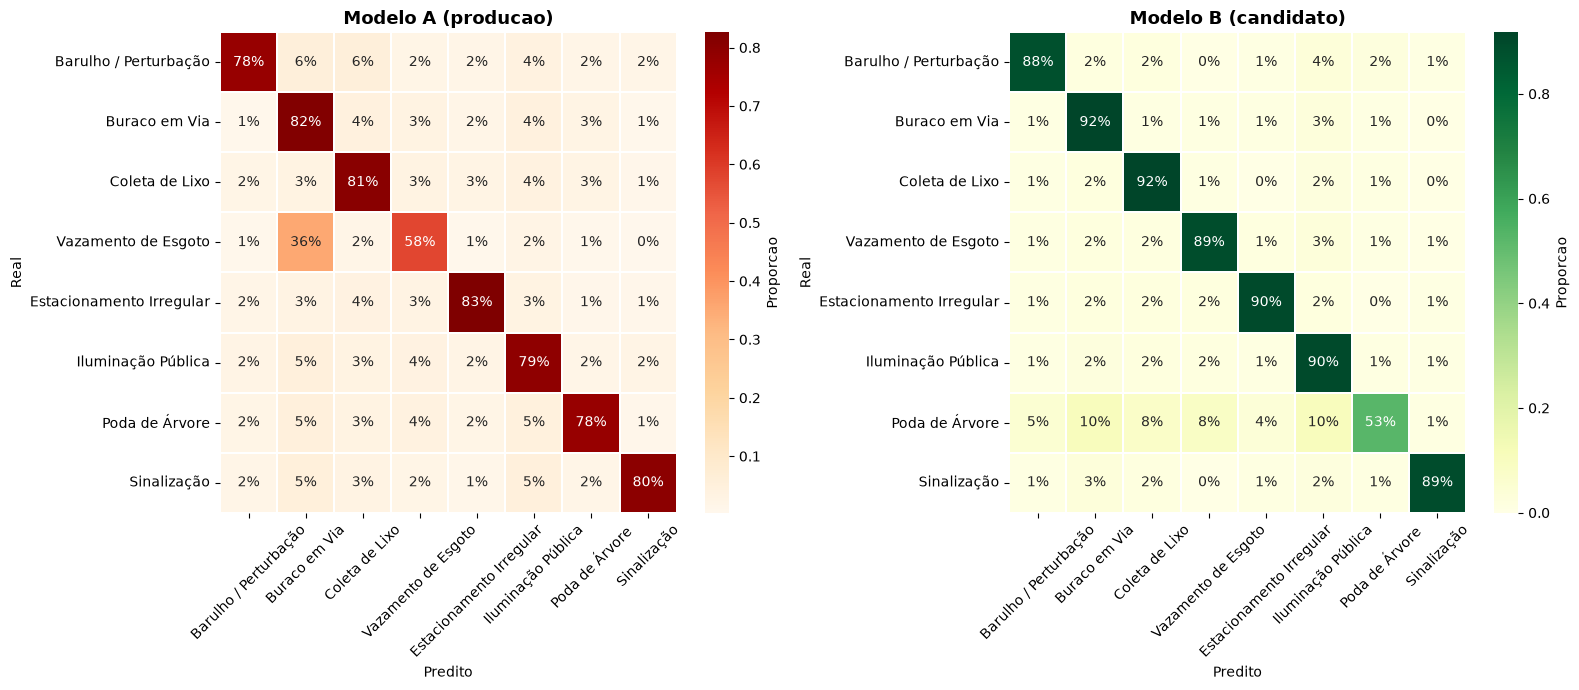

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax_idx, (y_pred, titulo, cmap) in enumerate([
    (y_pred_a, 'Modelo A (producao)', 'OrRd'),
    (y_pred_b, 'Modelo B (candidato)', 'YlGn')
]):
    cm = confusion_matrix(y_true, y_pred, labels=categorias)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=True, fmt='.0%', cmap=cmap,
                xticklabels=[cat_map[c] for c in categorias],
                yticklabels=[cat_map[c] for c in categorias],
                ax=axes[ax_idx], linewidths=0.3, cbar_kws={'label': 'Proporcao'})
    axes[ax_idx].set_title(titulo, fontweight='bold', fontsize=13)
    axes[ax_idx].set_xlabel('Predito')
    axes[ax_idx].set_ylabel('Real')
    axes[ax_idx].tick_params(axis='x', rotation=45)
    axes[ax_idx].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'matrizes_confusao_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2. Análise da Confiança

In [39]:
def calculate_ece(y_true, y_pred, confidence, n_bins=10):
    correct = (y_true == y_pred).astype(int)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0

    for i in range(n_bins):
        mask = (
            (confidence >= bins[i]) &
            (confidence < bins[i + 1])
        )
        
        if mask.sum() == 0:
            continue
        acc = correct[mask].mean()
        conf = confidence[mask].mean()
        ece += (mask.sum() / len(confidence)) * abs(acc - conf)

    return ece

In [40]:
ece_a = calculate_ece(
    df["categoria_real"],
    df["pred_modelo_a"],
    df["conf_modelo_a"]
)

ece_b = calculate_ece(
    df["categoria_real"],
    df["pred_modelo_b"],
    df["conf_modelo_b"]
)

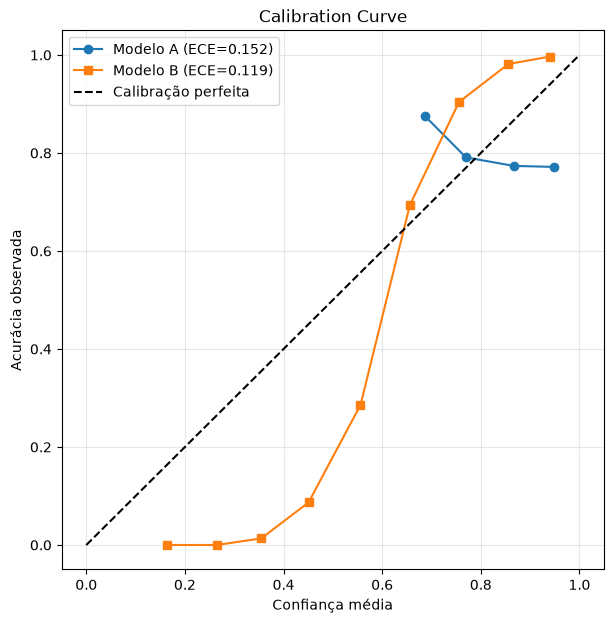

In [36]:
y_a = (df["pred_modelo_a"] == df["categoria_real"]).astype(int)
y_b = (df["pred_modelo_b"] == df["categoria_real"]).astype(int)

prob_a = df["conf_modelo_a"]
prob_b = df["conf_modelo_b"]

acc_a, conf_a = calibration_curve(
    y_a,
    prob_a,
    n_bins=10,
    strategy="uniform"
)

acc_b, conf_b = calibration_curve(
    y_b,
    prob_b,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7,7))

plt.plot(
    conf_a,
    acc_a,
    marker="o",
    label=f"Modelo A (ECE={ece_a:.3f})"
)

plt.plot(
    conf_b,
    acc_b,
    marker="s",
    label=f"Modelo B (ECE={ece_b:.3f})"
)

plt.plot([0,1], [0,1], "--", color="black", label="Calibração perfeita")

plt.xlabel("Confiança média")
plt.ylabel("Acurácia observada")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()